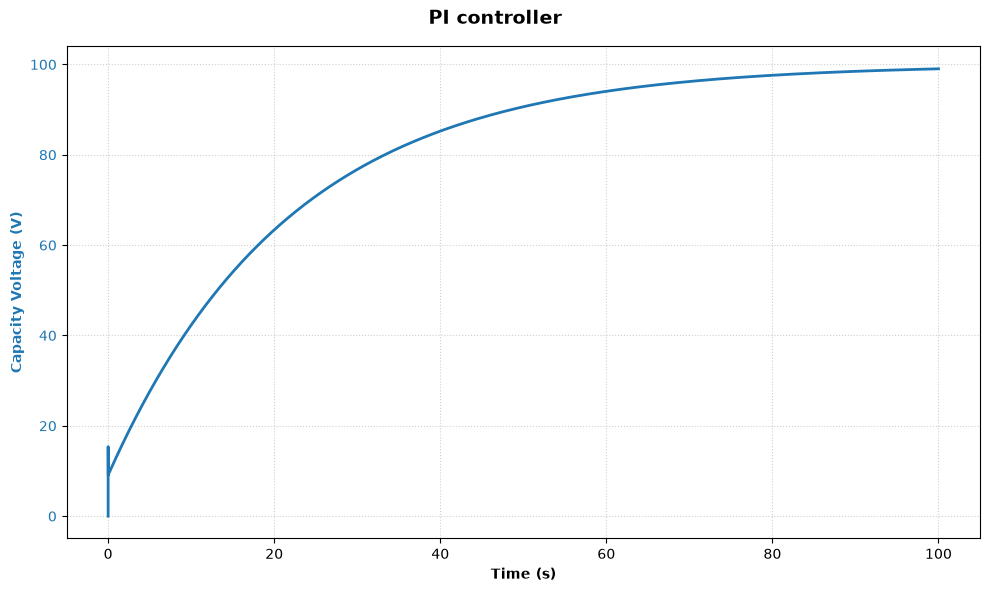

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Circuit Parameters & Simulation Setup
# ==========================================
r= 1.0  # Resistance in Ohms
v_ref=100
kp=0.1
ki=0.05
c = 100e-6  # Capacitance in Farads (100 uF)

t_start = 0.0
t_end = 100
dt = 0.001 # Time step (100 microseconds)
t = np.arange(t_start, t_end, dt)
N = len(t)

# ==========================================
# 2. State-Space Formulation
# ==========================================
# dx/dt = A*x + B*u
# x = [v_c; i_L]
A = np.array([[-(1+kp)/(r*c),ki/(r*c)], [-1, 0.0]])

B = np.array([[v_ref*kp/(r*c)], [v_ref]])

# ==========================================
# 3. Trapezoidal Integration Matrices
# ==========================================
# M1 = I - (dt/2)*A
# M2 = I + (dt/2)*A
# x_{k+1} = M1_inv * (M2 * x_k + (dt/2) * B * (u_k + u_{k+1}))
I = np.eye(2)
M1 = I - (dt / 2.0) * A
M2 = I + (dt / 2.0) * A
M1_inv = np.linalg.inv(M1)

# Precompute the input scaling term
B_term = (dt ) * B

# ==========================================
# 5. Simulation Loop
# ==========================================
# Initialize states: x = [v_c, i_L]^T
x = np.zeros((2, 1))

# Arrays to store history for plotting
vc_history = np.zeros(N)
i_history = np.zeros(N)

for k in range(N - 1):
    # Store current states
    vc_history[k] = x[0, 0]
    i_history[k] = x[1, 0]
 

    # Trapezoidal update step
    x_next = M1_inv @ (M2 @ x + B_term )
    x = x_next

# Store the final state values
vc_history[-1] = x[0, 0]
i_history[-1] = x[1, 0]

# ==========================================
# 6. Plotting results
# ==========================================
fig, axes = plt.subplots(1,1,figsize=(10, 6),sharex=True)

color = "tab:blue"
ax1=axes
ax1.set_xlabel("Time (s)", fontweight="bold")
ax1.set_ylabel("Capacity Voltage (V)", color=color, fontweight="bold")
ax1.plot(t, vc_history, color=color, label="PI controller integrator state variable", linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle=":", alpha=0.6)


fig.suptitle(
    "PI controller", fontsize=14, fontweight="bold"
)
fig.tight_layout()
plt.show()
